# 🧠 Sign Language Gesture Model Training
**SmartGlove Project** — Train a neural network to classify sign language gestures from flex sensor data.

### Workflow:
1. Mount Google Drive & load your `gesture_dataset_*.csv`
2. Explore & visualize the data
3. Train a classifier
4. Evaluate with confusion matrix
5. Export to **TensorFlow.js** (browser) + **TFLite** (ESP32)

> **Tip:** Use GPU runtime for faster training: `Runtime → Change runtime type → T4 GPU`

In [3]:
# ============= Install Dependencies =============
%pip install -q numpy pandas tensorflow scikit-learn matplotlib seaborn
print('✅ Core dependencies installed.')

print('ℹ️ Optional: tensorflowjs export is skipped on Windows in this notebook.')

Note: you may need to restart the kernel to use updated packages.
✅ Core dependencies installed.
ℹ️ Optional: tensorflowjs export is skipped on Windows in this notebook.


In [7]:
# ============= Imports =============
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from keras import layers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import importlib

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU Available: {tf.config.list_physical_devices("GPU")}')

TensorFlow version: 2.21.0
GPU Available: []


## 📂 Step 1: Load Dataset
Put your `gesture_dataset_*.csv` file in a folder (e.g., `Downloads/hand_glove/`).

**Edit the `DATASET_PATH` below** to point to your CSV file.

In [10]:
# ============= Locate Dataset (Colab or Local) =============
from pathlib import Path
from IPython import get_ipython

IN_COLAB = get_ipython() is not None and 'google.colab' in str(type(get_ipython()))
if IN_COLAB:
    drive = importlib.import_module('google.colab.drive')
    drive.mount('/content/drive')
    DATA_ROOT = Path('/content/drive/MyDrive/hand_glow')  # Change if needed
else:
    DATA_ROOT = Path.cwd()

print(f'📁 Searching for dataset in: {DATA_ROOT}')
patterns = ['gesture_dataset*.csv', 'handglow_dataset*.csv']
csv_files = []
for pattern in patterns:
    csv_files.extend(DATA_ROOT.glob(pattern))
csv_files = sorted(set(csv_files), key=lambda p: p.stat().st_mtime)

if csv_files:
    DATASET_PATH = str(csv_files[-1])
    print(f'✅ Found {len(csv_files)} dataset file(s):')
    for f in csv_files:
        size_kb = f.stat().st_size / 1024
        marker = ' 👈 SELECTED' if str(f) == DATASET_PATH else ''
        print(f'   • {f.name} ({size_kb:.1f} KB){marker}')
else:
    raise FileNotFoundError(
        f'No gesture_dataset*.csv or handglow_dataset*.csv found in {DATA_ROOT}. Place your dataset there or update DATA_ROOT.'
    )

📁 Searching for dataset in: c:\Users\user\Downloads\HandGlow-master(1)\HandGlow-master
✅ Found 1 dataset file(s):
   • handglow_dataset_1776628845226.csv (874.7 KB) 👈 SELECTED


In [11]:
# ============= Load Dataset =============
df = pd.read_csv(DATASET_PATH)

print(f'\n📊 Dataset: {os.path.basename(DATASET_PATH)}')
print(f'   Total samples: {len(df)}')
print(f'   Features: {len(df.columns) - 1}')
print(f'   Labels: {df["label"].nunique()}')
print(f'\n📋 Samples per label:')
print(df['label'].value_counts().to_string())

# Preview
df.head()


📊 Dataset: handglow_dataset_1776628845226.csv
   Total samples: 4914
   Features: 24
   Labels: 6

📋 Samples per label:
label
LOVE     1135
CALL      759
MILK      756
GOOD      755
HELLO     755
BAD       754


,label,hand_mode,recorded_hand,R.Thumb,R.Index,R.Middle,R.Ring,R.Pinky,L.Thumb,L.Index,...,aZ1,gX1,gY1,gZ1,aX2,aY2,aZ2,gX2,gY2,gZ2
0,GOOD,either_hand,right,0.0,1.0,1.0,1.0,1.0,0.0,0.0,...,-0.805,0.261,-0.495,0.886,0.9076,0.2869,3.948,0.0971,-1.7903,-0.6943
1,GOOD,either_hand,right,0.0,1.0,1.0,1.0,1.0,0.0,0.0,...,-0.831,0.262,-0.505,0.881,0.7876,3.8469,2.538,0.7971,-0.3603,0.0257
2,GOOD,either_hand,right,0.0,1.0,1.0,1.0,1.0,0.0,0.0,...,-0.845,0.253,-0.500,0.883,-1.5624,3.7769,1.138,0.1871,-2.6903,-1.4343
3,GOOD,either_hand,right,0.0,1.0,1.0,1.0,1.0,0.0,0.0,...,-0.830,0.263,-0.503,0.889,2.9776,6.0569,0.238,1.0971,-0.4403,-0.0343
4,GOOD,either_hand,right,0.0,1.0,1.0,1.0,1.0,0.0,0.0,...,-0.808,0.260,-0.500,0.881,3.2676,2.6169,0.998,0.1271,2.0897,2.5757


## 🔍 Step 2: Explore the Data

Feature columns (24):
  • hand_mode
  • recorded_hand
  • R.Thumb
  • R.Index
  • R.Middle
  • R.Ring
  • R.Pinky
  • L.Thumb
  • L.Index
  • L.Middle
  • L.Ring
  • L.Pinky
  • aX1
  • aY1
  • aZ1
  • gX1
  • gY1
  • gZ1
  • aX2
  • aY2
  • aZ2
  • gX2
  • gY2
  • gZ2


Feature columns (24):
  • hand_mode
  • recorded_hand
  • R.Thumb
  • R.Index
  • R.Middle
  • R.Ring
  • R.Pinky
  • L.Thumb
  • L.Index
  • L.Middle
  • L.Ring
  • L.Pinky
  • aX1
  • aY1
  • aZ1
  • gX1
  • gY1
  • gZ1
  • aX2
  • aY2
  • aZ2
  • gX2
  • gY2
  • gZ2


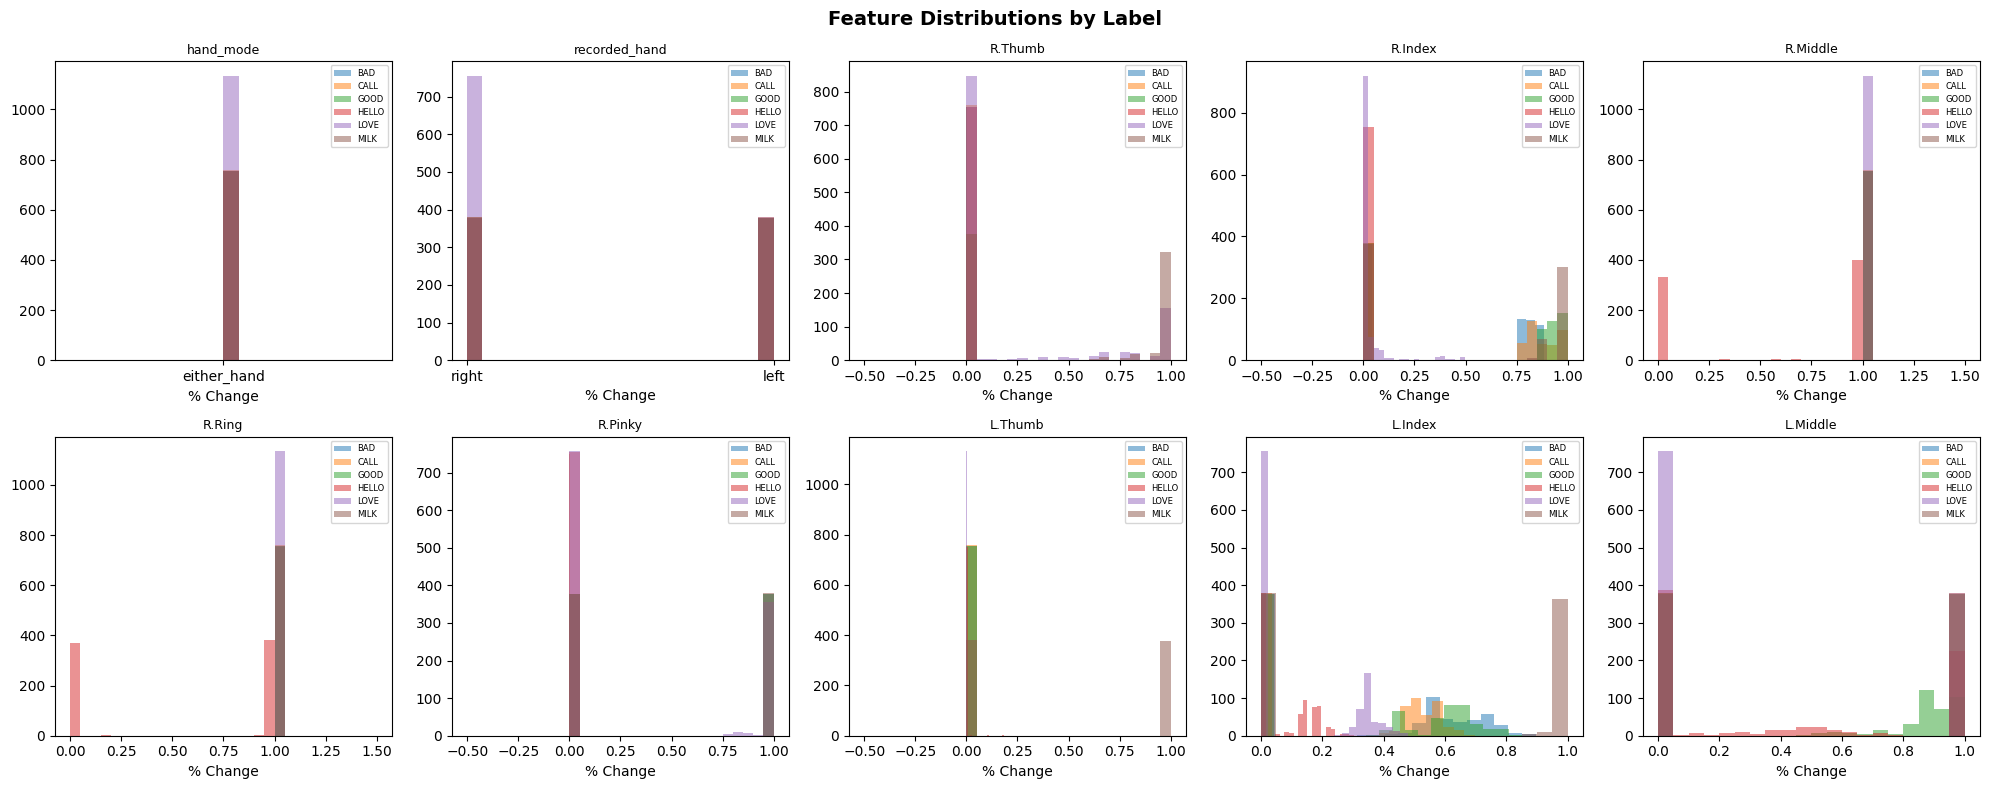

In [12]:
# ============= Feature Exploration =============
feature_cols = [c for c in df.columns if c != 'label']
print(f'Feature columns ({len(feature_cols)}):')
for c in feature_cols:
    print(f'  • {c}')

# Plot distributions
n_features = min(len(feature_cols), 10)
n_cols = 5
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
fig.suptitle('Feature Distributions by Label', fontsize=14, fontweight='bold')
axes = axes.flatten() if n_rows > 1 else [axes] if n_features == 1 else axes

for i, col in enumerate(feature_cols[:n_features]):
    ax = axes[i]
    for label in sorted(df['label'].unique()):
        subset = df[df['label'] == label][col]
        ax.hist(subset, bins=20, alpha=0.5, label=label)
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=6)
    ax.set_xlabel('% Change')

# Hide empty subplots
for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

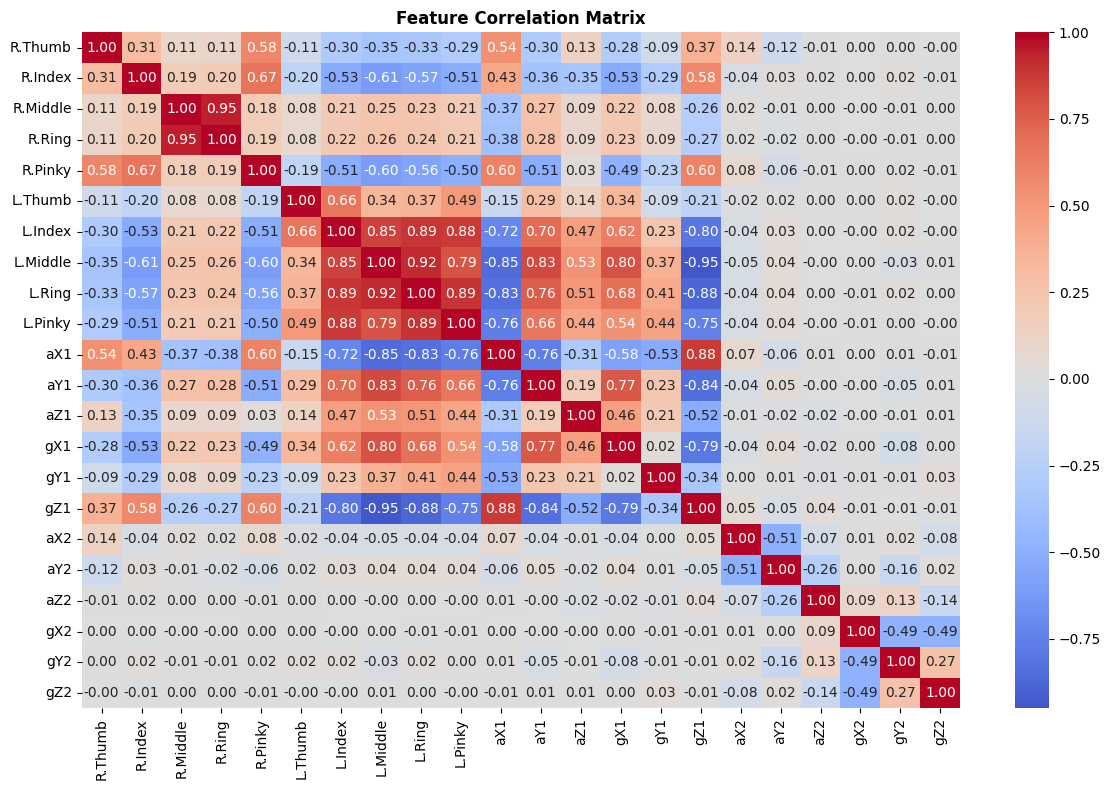

In [23]:
# ============= Correlation Heatmap =============
if 'feature_cols' not in globals():
    raise NameError('Run the previous feature exploration cell first so feature_cols is defined.')

numeric_feature_df = df[feature_cols].select_dtypes(include=[np.number])
if numeric_feature_df.empty:
    raise ValueError('No numeric feature columns were found for the correlation heatmap.')

plt.figure(figsize=(12, 8))
corr = numeric_feature_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=[c.replace('_pct', '') for c in corr.columns],
            yticklabels=[c.replace('_pct', '') for c in corr.columns])
plt.title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

## 🔧 Step 3: Prepare Data for Training

In [26]:
# ============= Prepare Features & Labels =============
# Use numeric features only (exclude text columns like hand_mode/recorded_hand)
train_feature_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

if not train_feature_cols:
    raise ValueError("No numeric feature columns available for training.")

X = df[train_feature_cols].values.astype(np.float32)
y_text = df['label'].values

# Encode labels
label_encoder = LabelEncoder()
y_int = label_encoder.fit_transform(y_text)
num_classes = len(label_encoder.classes_)
y = keras.utils.to_categorical(y_int, num_classes)

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_int
)

# Normalize (fit on train only)
feature_mean = X_train.mean(axis=0)
feature_std = X_train.std(axis=0) + 1e-8

X_train_norm = (X_train - feature_mean) / feature_std
X_test_norm = (X_test - feature_mean) / feature_std

print(f'Data prepared:')
print(f'   Input shape: {X.shape}')
print(f'   Features used ({len(train_feature_cols)}): {train_feature_cols}')
print(f'   Classes ({num_classes}): {list(label_encoder.classes_)}')
print(f'   Train: {X_train.shape[0]} samples')
print(f'   Test:  {X_test.shape[0]} samples')

Data prepared:
   Input shape: (4914, 22)
   Features used (22): ['R.Thumb', 'R.Index', 'R.Middle', 'R.Ring', 'R.Pinky', 'L.Thumb', 'L.Index', 'L.Middle', 'L.Ring', 'L.Pinky', 'aX1', 'aY1', 'aZ1', 'gX1', 'gY1', 'gZ1', 'aX2', 'aY2', 'aZ2', 'gX2', 'gY2', 'gZ2']
   Classes (6): ['BAD', 'CALL', 'GOOD', 'HELLO', 'LOVE', 'MILK']
   Train: 3931 samples
   Test:  983 samples


## 🏗️ Step 4: Build & Train Model

In [27]:
# ============= Build Model =============
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,374 (56.15 KB)

 Trainable params: 13,926 (54.40 KB)

 Non-trainable params: 448 (1.75 KB)

In [28]:
# ============= Train =============
early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=20,
    restore_best_weights=True, verbose=1
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=8, min_lr=1e-6, verbose=1
)

print('🏋️ Training...')
history = model.fit(
    X_train_norm, y_train,
    validation_data=(X_test_norm, y_test),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

🏋️ Training...
Epoch 1/200
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6487 - loss: 0.9988 - val_accuracy: 0.9054 - val_loss: 0.6049 - learning_rate: 0.0010
Epoch 2/200
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9232 - loss: 0.3070 - val_accuracy: 0.9959 - val_loss: 0.1061 - learning_rate: 0.0010
Epoch 3/200
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9707 - loss: 0.1436 - val_accuracy: 0.9980 - val_loss: 0.0215 - learning_rate: 0.0010
Epoch 4/200
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9827 - loss: 0.0905 - val_accuracy: 0.9980 - val_loss: 0.0081 - learning_rate: 0.0010
Epoch 5/200
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9883 - loss: 0.0618 - val_accuracy: 0.9980 - val_loss: 0.0053 - learning_rate: 0.0010
Epoch 6/200
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9939 - loss: 0.0426 - val_accuracy: 1.0000 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 7/200
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.

## 📈 Step 5: Evaluate

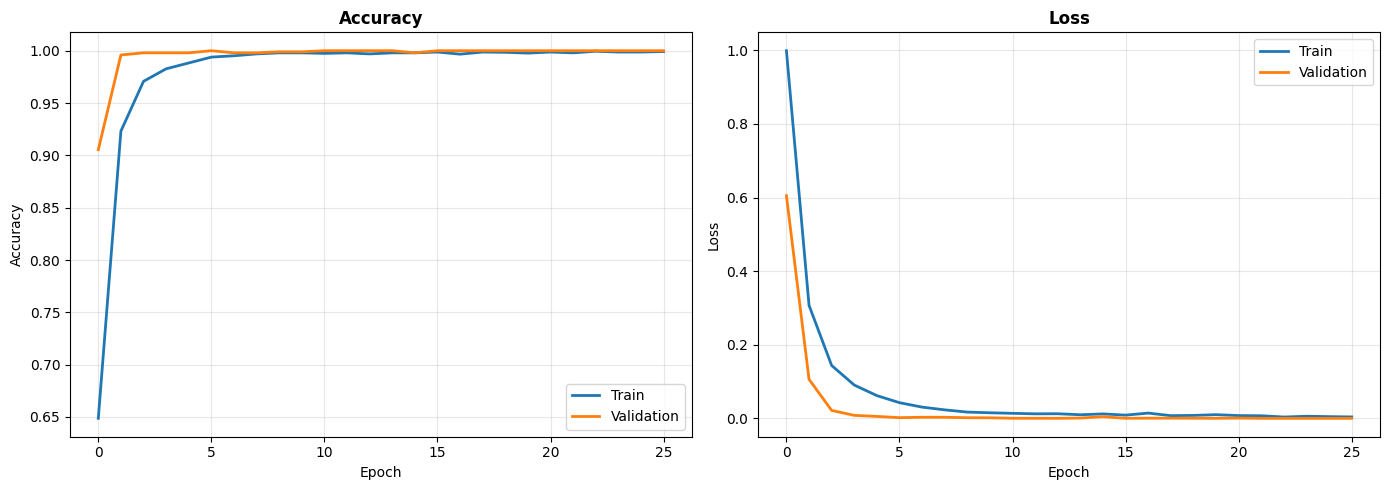

In [29]:
# ============= Training Curves =============
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
ax1.set_title('Accuracy', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'], label='Train', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation', linewidth=2)
ax2.set_title('Loss', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
📊 Classification Report:
              precision    recall  f1-score   support

         BAD       1.00      1.00      1.00       151
        CALL       1.00      1.00      1.00       152
        GOOD       1.00      1.00      1.00       151
       HELLO       1.00      1.00      1.00       151
        LOVE       1.00      1.00      1.00       227
        MILK       1.00      1.00      1.00       151

    accuracy                           1.00       983
   macro avg       1.00      1.00      1.00       983
weighted avg       1.00      1.00      1.00       983


🎯 Test Accuracy: 100.0%


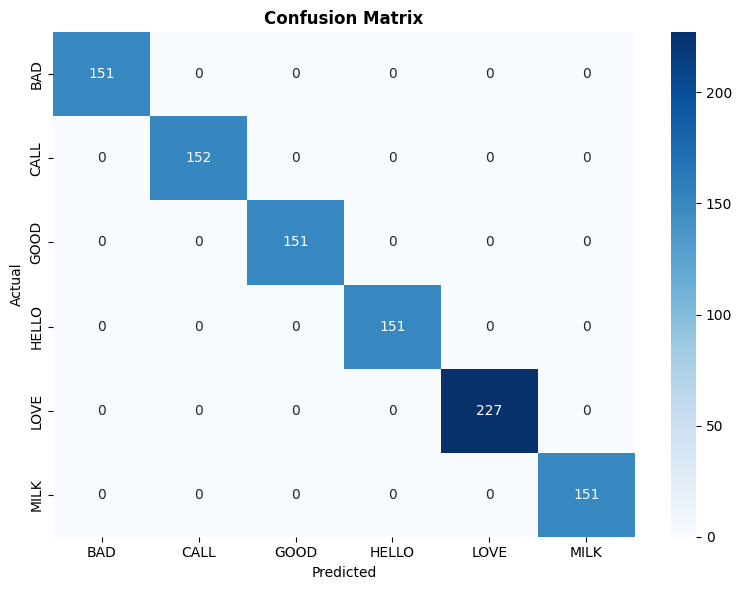

In [30]:
# ============= Classification Report & Confusion Matrix =============
y_pred = np.argmax(model.predict(X_test_norm), axis=1)
y_true = np.argmax(y_test, axis=1)

print('📊 Classification Report:')
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

test_loss, test_acc = model.evaluate(X_test_norm, y_test, verbose=0)
print(f'\n🎯 Test Accuracy: {test_acc*100:.1f}%')

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(max(8, num_classes), max(6, num_classes * 0.8)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 💾 Step 6: Export Models
Exports are saved **back to your Google Drive** so you can download them anytime.

In [31]:
# ============= Export Models (Colab or Local) =============
OUTPUT_DIR = os.path.join(str(DATA_ROOT), 'trained_model')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save metadata (labels + normalization stats)
metadata = {
    'labels': list(label_encoder.classes_),
    'num_classes': num_classes,
    'feature_columns': feature_cols,
    'num_features': len(feature_cols),
    'normalization': {
        'mean': feature_mean.tolist(),
        'std': feature_std.tolist()
    },
    'test_accuracy': float(test_acc),
    'trained_date': pd.Timestamp.now().isoformat()
}

# --- 1. TensorFlow.js model (optional) ---
tfjs_dir = os.path.join(OUTPUT_DIR, 'tfjs_model')
os.makedirs(tfjs_dir, exist_ok=True)
try:
    tfjs = importlib.import_module('tensorflowjs')
    tfjs.converters.save_keras_model(model, tfjs_dir)
    with open(os.path.join(tfjs_dir, 'model_metadata.json'), 'w') as f:
        json.dump(metadata, f, indent=2)
    print(f'✅ TF.js model saved: {tfjs_dir}')
except Exception as e:
    print(f'⚠️ Skipping TF.js export: {e}')
    print('   You can run TF.js export in Colab/WSL/Linux if needed.')

# --- 2. TFLite model (for ESP32) ---
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model = converter.convert()

tflite_path = os.path.join(OUTPUT_DIR, 'gesture_model.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f'\n✅ TFLite model: {tflite_path} ({len(tflite_model)/1024:.1f} KB)')

# --- 3. C header for ESP32 ---
c_path = os.path.join(OUTPUT_DIR, 'gesture_model.h')
with open(c_path, 'w') as f:
    f.write(f'// Auto-generated - {pd.Timestamp.now().isoformat()}\n')
    f.write(f'// Classes: {list(label_encoder.classes_)}\n')
    f.write(f'// Accuracy: {test_acc*100:.1f}%\n\n')
    f.write(f'const unsigned int gesture_model_len = {len(tflite_model)};\n')
    f.write('const unsigned char gesture_model[] = {\n  ')
    for i, byte in enumerate(tflite_model):
        f.write(f'0x{byte:02x}')
        if i < len(tflite_model) - 1:
            f.write(', ')
        if (i + 1) % 12 == 0:
            f.write('\n  ')
    f.write('\n};\n')

labels_path = os.path.join(OUTPUT_DIR, 'gesture_labels.h')
with open(labels_path, 'w') as f:
    f.write(f'const int NUM_GESTURES = {num_classes};\n')
    f.write('const char* GESTURE_LABELS[] = {\n')
    for i, label in enumerate(label_encoder.classes_):
        comma = ',' if i < num_classes - 1 else ''
        f.write(f'  "{label}"{comma}\n')
    f.write('};\n')

# --- 4. Save Keras model ---
keras_path = os.path.join(OUTPUT_DIR, 'gesture_model.keras')
model.save(keras_path)

# Save metadata at OUTPUT_DIR as fallback even if TF.js export is skipped
with open(os.path.join(OUTPUT_DIR, 'model_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'\n✅ All files saved to:')
print(f'   📁 {OUTPUT_DIR}')
for root, dirs, fnames in os.walk(OUTPUT_DIR):
    level = root.replace(OUTPUT_DIR, '').count(os.sep)
    indent = '   ' + '  ' * level
    for fname in sorted(fnames):
        fpath = os.path.join(root, fname)
        fsize = os.path.getsize(fpath) / 1024
        print(f'{indent}• {fname} ({fsize:.1f} KB)')

⚠️ Skipping TF.js export: No module named 'tensorflowjs'
   You can run TF.js export in Colab/WSL/Linux if needed.
INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmpf3dwu5co\assets


INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmpf3dwu5co\assets


Saved artifact at 'C:\Users\user\AppData\Local\Temp\tmpf3dwu5co'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 22), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2231489071440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2231489072592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2231489074128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2231489073744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2231489074512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2231489074320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2231489073552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2231489072400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2231489075472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2231489075664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2231489074896: 

## 🔮 Step 7: Test Predictions

In [32]:
# ============= Sample Predictions =============
print('🔮 Sample predictions on test data:\n')
for i in range(min(15, len(X_test))):
    sample = X_test_norm[i:i+1]
    pred = model.predict(sample, verbose=0)
    pred_label = label_encoder.classes_[np.argmax(pred)]
    true_label = label_encoder.classes_[y_true[i]]
    confidence = np.max(pred) * 100
    match = '✅' if pred_label == true_label else '❌'
    print(f'  {match} True: {true_label:>8s}  →  Predicted: {pred_label:>8s}  ({confidence:.1f}%)')

🔮 Sample predictions on test data:

  ✅ True:     LOVE  →  Predicted:     LOVE  (99.9%)
  ✅ True:     GOOD  →  Predicted:     GOOD  (100.0%)
  ✅ True:      BAD  →  Predicted:      BAD  (100.0%)
  ✅ True:     MILK  →  Predicted:     MILK  (99.9%)
  ✅ True:     GOOD  →  Predicted:     GOOD  (100.0%)
  ✅ True:     MILK  →  Predicted:     MILK  (99.9%)
  ✅ True:      BAD  →  Predicted:      BAD  (100.0%)
  ✅ True:    HELLO  →  Predicted:    HELLO  (99.7%)
  ✅ True:     CALL  →  Predicted:     CALL  (99.9%)
  ✅ True:    HELLO  →  Predicted:    HELLO  (99.8%)
  ✅ True:      BAD  →  Predicted:      BAD  (99.9%)
  ✅ True:      BAD  →  Predicted:      BAD  (99.9%)
  ✅ True:     MILK  →  Predicted:     MILK  (99.9%)
  ✅ True:     LOVE  →  Predicted:     LOVE  (99.9%)
  ✅ True:     CALL  →  Predicted:     CALL  (99.9%)


## 🌐 Step 8: How to Use in Browser

Download the `tfjs_model/` folder from your Google Drive and place it in your `hand_glow/` project folder.

```html
<script src="https://cdn.jsdelivr.net/npm/@tensorflow/tfjs"></script>
<script>
  // Load model + metadata
  const model = await tf.loadLayersModel('tfjs_model/model.json');
  const meta = await fetch('tfjs_model/model_metadata.json').then(r => r.json());

  // Normalize live sensor data the same way as training
  function predict(pctValues) {
    const normalized = pctValues.map((v, i) =>
      (v - meta.normalization.mean[i]) / meta.normalization.std[i]
    );
    const input = tf.tensor2d([normalized]);
    const prediction = model.predict(input);
    const classIndex = prediction.argMax(-1).dataSync()[0];
    const confidence = prediction.max().dataSync()[0];
    input.dispose(); prediction.dispose();
    return { label: meta.labels[classIndex], confidence };
  }
</script>
```